# Equations
### Local (disk surface)
$$
\mathrm{St}_{s,S}=\frac{\pi}{2}\frac{\rho_{\rm int}a_s}{\Sigma_g}\exp\!\left(\frac{z^2}{2H_g^2}\right)
$$

$$
\beta_{\rm rad,d}=\frac{c_d\Omega}{16\,\sigma_{\rm SB}\kappa_{P,d}T_{\rm eq}^3},\quad
\beta_{\rm rad,g}=\frac{c_p\Omega}{16\,\sigma_{\rm SB}\kappa_{P,d}(\rho_d/\rho_g)T_{\rm eq}^3}
$$

$$
\beta_{\rm col,d}=\alpha_T^{-1}\frac{2}{3}\frac{\gamma_g}{\gamma_g-1}\frac{c_d}{c_p}\,\mathrm{St}_{s,S},\quad
\beta_{\rm col,g}=\alpha_T^{-1}\frac{2}{3}\frac{\gamma_g}{\gamma_g-1}\frac{\rho_g}{\rho_d}\,\mathrm{St}_{s,S}
$$

### Vertically integrated (disk interior)

$$
\tau_{\rm eff}=\frac{3\tau_{R,d}}{8}+\frac{\sqrt{3}}{4}+\frac{1}{4\tau_{P,d}},\quad
\tau_{R,d}=\frac{\kappa_{R,d}\Sigma_d}{2},\quad
\tau_{P,d}=\frac{\kappa_{P,d}\Sigma_d}{2}
$$

$$
\mathrm{St}_{\rm mid,S}=\frac{\pi}{2}\frac{a_s\rho_{\rm int}}{\Sigma_g}
$$

$$
\beta_{\rm rad,d}=\frac{\Sigma_d c_d\tau_{\rm eff}\Omega}{8\sigma_{\rm SB}T_{\rm eq}^3},\quad
\beta_{\rm rad,g}=\frac{\Sigma_g c_p\tau_{\rm eff}\Omega}{8\sigma_{\rm SB}T_{\rm eq}^3}
$$

$$
\beta_{\rm col,d}=\alpha_T^{-1}\frac{2}{3}\frac{\gamma_g}{\gamma_g-1}\frac{c_d}{c_p}\sqrt{1+(H_d/H_g)^2}\,\mathrm{St}_{\rm mid,S}
$$

$$
\beta_{\rm col,g}=\alpha_T^{-1}\frac{2}{3}\frac{\gamma_g}{\gamma_g-1}\frac{\Sigma_g}{\Sigma_d}\sqrt{1+(H_d/H_g)^2}\,\mathrm{St}_{\rm mid,S}
$$

In [10]:
import numpy as np

# Minimal notebook-ready script to explore cooling timescales vs physical inputs


# --- Constants (cgs) ---
sigma_SB = 5.670374419e-5   # Stefan-Boltzmann constant [erg cm^-2 s^-1 K^-4]
G = 6.67430e-8              # Gravitational constant [cm^3 g^-1 s^-2]
M_sun = 1.98847e33          # Solar mass [g]
AU = 1.495978707e13         # Astronomical unit [cm]

In [24]:
# Scenario 1: Local cooling at the disk surface

def keplerian_omega(r_AU, M_star_Msun):
    r = r_AU * AU
    M = M_star_Msun * M_sun
    return np.sqrt(G * M / r**3)

def local_surface_cooling(
    a_s, rho_int, Sigma_g, z_over_Hg, c_d, c_p, kappa_P_d, T_eq,
    gas_dust_ratio_vol, alpha_T, gamma_g, Omega
):
    # gas_dust_ratio_vol = rho_g / rho_d
    dust_to_gas_ratio_vol = 1.0 / gas_dust_ratio_vol

    St_s_S = (np.pi / 2.0) * (rho_int * a_s / Sigma_g) * np.exp(0.5 * z_over_Hg**2)

    beta_rad_d = (c_d * Omega) / (16.0 * sigma_SB * kappa_P_d * T_eq**3)
    beta_rad_g = (c_p * Omega) / (16.0 * sigma_SB * kappa_P_d * dust_to_gas_ratio_vol * T_eq**3)

    pref = (1.0 / alpha_T) * (2.0 / 3.0) * (gamma_g / (gamma_g - 1.0))
    beta_col_d = pref * (c_d / c_p) * St_s_S
    beta_col_g = pref * gas_dust_ratio_vol * St_s_S

    return {
        "St_s_S": St_s_S,
        "beta_rad_d": beta_rad_d,
        "beta_rad_g": beta_rad_g,
        "beta_col_d": beta_col_d,
        "beta_col_g": beta_col_g,
    }

# --- Inputs for disk surface scenario (relevant only) ---
surface_inputs = dict(
    r_AU=50.0,
    M_star_Msun=1.0,
    a_s=1e-3,                     # grain size [cm]
    rho_int=1.0,                 # grain internal density [g cm^-3]
    Sigma_g=100.0,               # gas surface density [g cm^-2]
    z_over_Hg=3.0,               # height in units of H_g
    c_d=1e7,                     # dust heat capacity [erg g^-1 K^-1]
    c_p=1e8,                     # gas heat capacity [erg g^-1 K^-1]
    kappa_P_d=10.0,              # Planck mean opacity [cm^2 g^-1]
    T_eq=100.0,                  # equilibrium temperature [K]
    gas_dust_ratio_vol=100.0,    # rho_g / rho_d
    alpha_T=1,                # thermal coupling parameter
    gamma_g=1.4,                 # adiabatic index
)

Omega_surface = keplerian_omega(surface_inputs["r_AU"], surface_inputs["M_star_Msun"])
surface_out = local_surface_cooling(
    a_s=surface_inputs["a_s"],
    rho_int=surface_inputs["rho_int"],
    Sigma_g=surface_inputs["Sigma_g"],
    z_over_Hg=surface_inputs["z_over_Hg"],
    c_d=surface_inputs["c_d"],
    c_p=surface_inputs["c_p"],
    kappa_P_d=surface_inputs["kappa_P_d"],
    T_eq=surface_inputs["T_eq"],
    gas_dust_ratio_vol=surface_inputs["gas_dust_ratio_vol"],
    alpha_T=surface_inputs["alpha_T"],
    gamma_g=surface_inputs["gamma_g"],
    Omega=Omega_surface, 
)

print("Scenario 1: Disk surface")
print("Omega [s^-1]:", Omega_surface)
for k, v in surface_out.items():
    print(f"  {k:16s} = {v:.6e}")

Scenario 1: Disk surface
Omega [s^-1]: 5.631437374853379e-10
  St_s_S           = 1.413986e-03
  beta_rad_d       = 6.207083e-07
  beta_rad_g       = 6.207083e-04
  beta_col_d       = 3.299300e-04
  beta_col_g       = 3.299300e-01


In [25]:
# Scenario 2: Vertically integrated cooling in the disk interior

def keplerian_omega(r_AU, M_star_Msun):
    r = r_AU * AU
    M = M_star_Msun * M_sun
    return np.sqrt(G * M / r**3)

def vertical_integrated_cooling(
    a_s, rho_int, Sigma_g, gas_dust_ratio_vert_int, kappa_R_d, kappa_P_d, c_d, c_p, T_eq,
    alpha_T, gamma_g, Hd_over_Hg, Omega
):
    # gas_dust_ratio_vert_int = Sigma_g / Sigma_d
    Sigma_d = Sigma_g / gas_dust_ratio_vert_int

    tau_R_d = 0.5 * kappa_R_d * Sigma_d
    tau_P_d = 0.5 * kappa_P_d * Sigma_d
    tau_eff = (3.0 * tau_R_d / 8.0) + (np.sqrt(3.0) / 4.0) + (1.0 / (4.0 * tau_P_d))

    St_mid_S = (np.pi / 2.0) * (a_s * rho_int / Sigma_g)

    beta_rad_d = (Sigma_d * c_d * tau_eff * Omega) / (8.0 * sigma_SB * T_eq**3)
    beta_rad_g = (Sigma_g * c_p * tau_eff * Omega) / (8.0 * sigma_SB * T_eq**3)

    pref = (1.0 / alpha_T) * (2.0 / 3.0) * (gamma_g / (gamma_g - 1.0))
    geom = np.sqrt(1.0 + Hd_over_Hg ** 2)
    beta_col_d = pref * (c_d / c_p) * geom * St_mid_S
    beta_col_g = pref * gas_dust_ratio_vert_int * geom * St_mid_S

    return {
        "Sigma_d": Sigma_d,
        "tau_R_d": tau_R_d,
        "tau_P_d": tau_P_d,
        "tau_eff": tau_eff,
        "St_mid_S": St_mid_S,
        "beta_rad_d": beta_rad_d,
        "beta_rad_g": beta_rad_g,
        "beta_col_d": beta_col_d,
        "beta_col_g": beta_col_g,
    }

# --- Inputs for disk interior scenario (relevant only) ---
interior_inputs = dict(
    r_AU=50.0,
    M_star_Msun=1.0,
    a_s=1e-1,                     # grain size [cm]
    rho_int=1.0,                  # grain internal density [g cm^-3]
    Sigma_g=100.0,                # gas surface density [g cm^-2]
    gas_dust_ratio_vert_int=100.0,  # Sigma_g / Sigma_d
    kappa_R_d=10.0,               # Rosseland mean opacity [cm^2 g^-1]
    kappa_P_d=10.0,               # Planck mean opacity [cm^2 g^-1]
    c_d=1e7,                      # dust heat capacity [erg g^-1 K^-1]
    c_p=1e8,                      # gas heat capacity [erg g^-1 K^-1]
    T_eq=30.0,                    # equilibrium temperature [K]
    alpha_T=1,                    # thermal coupling parameter
    gamma_g=1.4,                  # adiabatic index
    Hd_over_Hg=0.2,               # H_d / H_g
)

Omega_interior = keplerian_omega(interior_inputs["r_AU"], interior_inputs["M_star_Msun"])
interior_out = vertical_integrated_cooling(
    a_s=interior_inputs["a_s"],
    rho_int=interior_inputs["rho_int"],
    Sigma_g=interior_inputs["Sigma_g"],
    gas_dust_ratio_vert_int=interior_inputs["gas_dust_ratio_vert_int"],
    kappa_R_d=interior_inputs["kappa_R_d"],
    kappa_P_d=interior_inputs["kappa_P_d"],
    c_d=interior_inputs["c_d"],
    c_p=interior_inputs["c_p"],
    T_eq=interior_inputs["T_eq"],
    alpha_T=interior_inputs["alpha_T"],
    gamma_g=interior_inputs["gamma_g"],
    Hd_over_Hg=interior_inputs["Hd_over_Hg"],
    Omega=Omega_interior, 
)

print("Scenario 2: Disk interior")
print("Omega [s^-1]:", Omega_interior)
for k, v in interior_out.items():
    print(f"  {k:16s} = {v:.6e}")

Scenario 2: Disk interior
Omega [s^-1]: 5.631437374853379e-10
  Sigma_d          = 1.000000e+00
  tau_R_d          = 5.000000e+00
  tau_P_d          = 5.000000e+00
  tau_eff          = 2.358013e+00
  St_mid_S         = 1.570796e-03
  beta_rad_d       = 1.084176e-03
  beta_rad_g       = 1.084176e+00
  beta_col_d       = 3.737777e-04
  beta_col_g       = 3.737777e-01


## Local cooling timescales from first principles

Assumptions:
- $\kappa_P = \kappa_R = (T/2\,\mathrm{K})^{1.7}$ cm² g⁻¹
- Equilibrium temperature (eliminating $\kappa_P(T_{eq})$):
$$T_{eq} = T_* \left(\frac{R_*}{2R}\right)^{2/5.7}$$
- Surface density power law: $\Sigma_g(R) = \Sigma_{g,1\mathrm{AU}}\,(R/1\,\mathrm{AU})^{-1}$
- Dust heat capacity: $c_d(T) = 10\,(T/1\,\mathrm{K})^{3}$ erg g⁻¹ K⁻¹
- Gas heat capacity: $c_p = \tfrac{7}{2}\,\frac{k_B}{\mu m_H}$ with $\mu=2.3$

Required: `a_s`, `Sigma_g_1au`, `R`; all other parameters have defaults.

In [30]:
import numpy as np

# ── Constants (cgs) ──────────────────────────────────────────────────────────
sigma_SB = 5.670374419e-5   # Stefan-Boltzmann [erg cm^-2 s^-1 K^-4]
G        = 6.67430e-8       # Gravitational constant [cm^3 g^-1 s^-2]
k_B      = 1.380649e-16     # Boltzmann constant [erg K^-1]
m_H      = 1.6735575e-24    # Hydrogen mass [g]
M_sun    = 1.98847e33       # Solar mass [g]
R_sun    = 6.957e10         # Solar radius [cm]
T_sun    = 5778.0           # Solar effective temperature [K]
AU       = 1.495978707e13   # Astronomical unit [cm]

# ── Model prescriptions ───────────────────────────────────────────────────────
# kappa_P = kappa_R = (T/2 K)^1.7  [cm^2/g]
# T_eq = T_* * (R_* / (2R))^(2/5.7)   [derived by eliminating kappa_P(T_eq)]
# Sigma_g(R) = Sigma_g_1au * (R/1AU)^{-1}
# c_d(T) = 10 * T^3                    [erg g^-1 K^-1]
# c_p    = 7/2 * k_B / (mu * m_H)     [erg g^-1 K^-1]

def kappa_mean(T):
    """Planck / Rosseland mean opacity [cm^2/g]."""
    return (T / 2.0) ** 1.7

def T_eq_formula(T_star, R_star, R_AU):
    """Equilibrium temperature [K] from stellar irradiation.

    Derived by substituting kappa_P(T) = (T/2)^1.7 into
      T_eq = [kappa_P(T_eq)/kappa_P(T_*)]^{-1/4} * (R_*/(2R))^{1/2} * T_*
    and solving for T_eq:
      T_eq = T_* * (R_* / (2R))^{2/(4+1.7)}
    """
    R_cm = R_AU * AU
    return T_star * (R_star / (2.0 * R_cm)) ** (2.0 / 5.7)


def local_cooling_betas(
    a_s,                          # grain size [cm]                   ← required
    Sigma_g_1au,                  # gas surface density at 1 AU [g cm^-2]  ← required
    R,                            # orbital radius [AU]               ← required
    rho_g_over_rho_d = 100.0,    # volumetric gas-to-dust ratio ρ_g/ρ_d
    T_star           = T_sun,     # stellar effective temperature [K]
    M_star           = M_sun,     # stellar mass [g]
    R_star           = R_sun,     # stellar radius [cm]
    alpha_T          = 1.0,       # thermal accommodation coefficient (α_T)
    rho_int          = 1.0,     # grain internal density [g cm^-3]
    gamma_g          = 1.4,       # adiabatic index
    mu               = 2.3,       # mean molecular weight
    z_over_Hg        = 3.0,       # height z/H_g (0 = midplane)
):
    """Return dimensionless cooling timescales β = t_cool * Ω for the local
    (disk-surface) scenario.

    Parameters
    ----------
    a_s              : grain size [cm]
    Sigma_g_1au      : gas surface density at 1 AU [g cm^-2]; Σ_g(R) = Σ_{g,1AU} * (R/AU)^{-1}
    R                : orbital radius [AU]
    rho_g_over_rho_d : ρ_g / ρ_d (volumetric); default 100
    T_star           : stellar effective temperature [K]; default T_sun
    M_star           : stellar mass [g]; default M_sun
    R_star           : stellar radius [cm]; default R_sun
    alpha_T          : thermal accommodation coefficient; default 1
    rho_int          : grain internal density [g cm^-3]; default 1.0
    gamma_g          : adiabatic index; default 1.4
    mu               : mean molecular weight; default 2.3
    z_over_Hg        : height z/H_g; default 3.0

    Returns
    -------
    dict with Sigma_g, T_eq, kappa_P, c_d, c_p, Omega, St, and all four β values.

    β formulas (local / disk-surface):
      β_rad,d  = c_d Ω / (16 σ_SB κ_P T_eq^3)
      β_rad,g  = c_p (ρ_g/ρ_d) Ω / (16 σ_SB κ_P T_eq^3)
      β_col,d  = α_T^{-1} · (2/3) · γ/(γ-1) · (c_d/c_p) · St
      β_col,g  = α_T^{-1} · (2/3) · γ/(γ-1) · (ρ_g/ρ_d) · St
    with  St = (π/2) · ρ_int a_s / Σ_g · exp(z²/2H_g²)
    """
    # ── Surface density from power-law profile ───────────────────────────────
    Sigma_g = Sigma_g_1au * (R / 1.0) ** (-1.0)    # Σ_g(R) = Σ_{g,1AU} * (R/AU)^{-1}

    # ── Derived quantities ───────────────────────────────────────────────────
    Omega   = np.sqrt(G * M_star / (R * AU)**3)     # Keplerian angular velocity [s^-1]
    T_eq    = T_eq_formula(T_star, R_star, R)        # equilibrium temperature [K]
    kappa_P = kappa_mean(T_eq)                       # opacity at T_eq [cm^2/g]
    c_d     = 10.0 * T_eq**3                         # dust heat capacity [erg g^-1 K^-1]
    c_p     = (7.0 / 2.0) * k_B / (mu * m_H)        # gas heat capacity  [erg g^-1 K^-1]

    # Stokes number (local, at height z)
    St = (np.pi / 2.0) * (rho_int * a_s / Sigma_g) * np.exp(0.5 * z_over_Hg**2)

    # ── Radiative β (dust and gas) ───────────────────────────────────────────
    common_rad  = Omega / (16.0 * sigma_SB * kappa_P * T_eq**3)
    beta_rad_d  = c_d * common_rad
    beta_rad_g  = c_p * rho_g_over_rho_d * common_rad

    # ── Collisional β (dust and gas) ─────────────────────────────────────────
    pref        = (1.0 / alpha_T) * (2.0 / 3.0) * (gamma_g / (gamma_g - 1.0))
    beta_col_d  = pref * (c_d / c_p) * St
    beta_col_g  = pref * rho_g_over_rho_d * St

    return dict(
        Sigma_g    = Sigma_g,
        T_eq       = T_eq,
        kappa_P    = kappa_P,
        c_d        = c_d,
        c_p        = c_p,
        Omega      = Omega,
        St         = St,
        beta_rad_d = beta_rad_d,
        beta_rad_g = beta_rad_g,
        beta_col_d = beta_col_d,
        beta_col_g = beta_col_g,
    )


# ── Example call (only three required parameters) ────────────────────────────
# Σ_{g,1AU} = 500 g/cm² → Σ_g(50 AU) = 100 g/cm²
result = local_cooling_betas(
    a_s         = 10e-4,   # 10 μm  [cm]
    Sigma_g_1au = 500.0,  # [g cm^-2] at 1 AU  →  100 g/cm² at 50 AU
    R           = 50.0,    # [AU]
)

print("Local cooling timescales  (a_s=10 μm, Σ_{g,1AU}=500 g/cm², R=50 AU)")
print(f"  Σ_g(R)      = {result['Sigma_g']:.2f} g/cm²")
print(f"  T_eq        = {result['T_eq']:.2f} K")
print(f"  κ_P(T_eq)   = {result['kappa_P']:.4f} cm²/g")
print(f"  c_d(T_eq)   = {result['c_d']:.4e} erg/g/K")
print(f"  c_p         = {result['c_p']:.4e} erg/g/K")
print(f"  Ω           = {result['Omega']:.4e} s⁻¹")
print(f"  St          = {result['St']:.4e}")
print()
print(f"  β_rad,d  = {result['beta_rad_d']:.4e}   (dust radiative)")
print(f"  β_rad,g  = {result['beta_rad_g']:.4e}   (gas radiative)")
print(f"  β_col,d  = {result['beta_col_d']:.4e}   (dust collisional)")
print(f"  β_col,g  = {result['beta_col_g']:.4e}   (gas collisional)")


Local cooling timescales  (a_s=10 μm, Σ_{g,1AU}=500 g/cm², R=50 AU)
  Σ_g(R)      = 10.00 g/cm²
  T_eq        = 174.42 K
  κ_P(T_eq)   = 1990.5383 cm²/g
  c_d(T_eq)   = 5.3064e+07 erg/g/K
  c_p         = 1.2554e+08 erg/g/K
  Ω           = 5.6314e-10 s⁻¹
  St          = 1.4140e-02

  β_rad,d  = 3.1183e-09   (dust radiative)
  β_rad,g  = 7.3773e-07   (gas radiative)
  β_col,d  = 1.3946e-02   (dust collisional)
  β_col,g  = 3.2993e+00   (gas collisional)


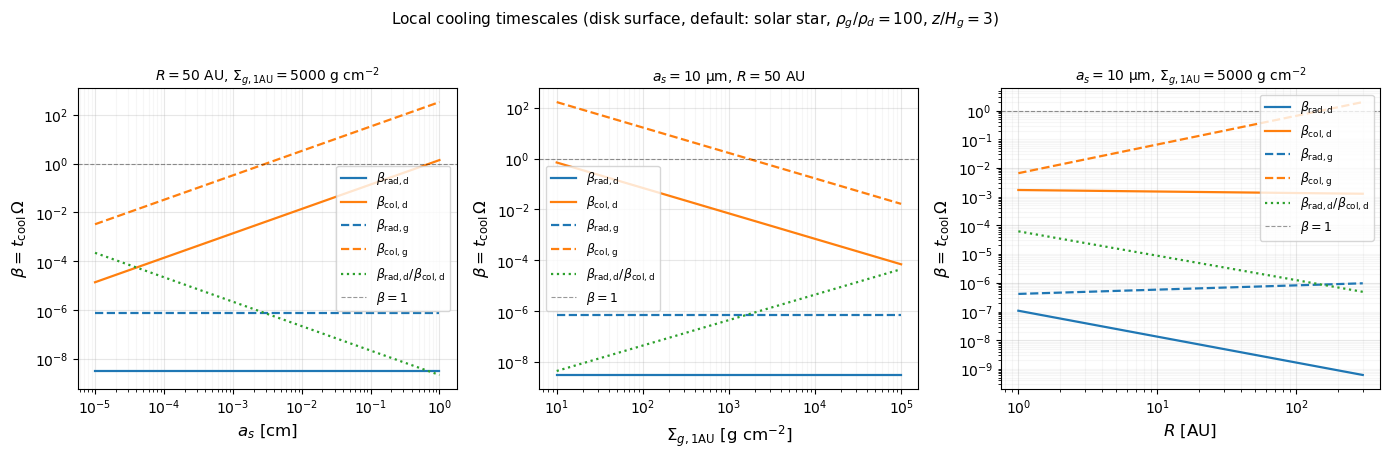

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Fiducial parameters ───────────────────────────────────────────────────────
fid = dict(
    a_s         = 10e-4,    # 10 μm [cm]
    Sigma_g_1au = 5000.0,   # [g cm^-2]
    R           = 50.0,     # [AU]
)

LABELS = {
    "beta_rad_d": (r"$\beta_{\rm rad,d}$",  "C0", "-"),
    "beta_col_d": (r"$\beta_{\rm col,d}$",  "C1", "-"),
    "beta_rad_g": (r"$\beta_{\rm rad,g}$",  "C0", "--"),
    "beta_col_g": (r"$\beta_{\rm col,g}$",  "C1", "--"),
    "ratio_d":    (r"$\beta_{\rm rad,d}/\beta_{\rm col,d}$", "C2", ":"),
}

def compute_array(sweep_key, sweep_vals, **fixed):
    """Evaluate local_cooling_betas over an array, returning dict of arrays."""
    keys = list(LABELS.keys())
    out  = {k: np.empty(len(sweep_vals)) for k in keys}
    for i, v in enumerate(sweep_vals):
        kw = dict(fixed)
        kw[sweep_key] = v
        r = local_cooling_betas(**kw)
        out["beta_rad_d"][i] = r["beta_rad_d"]
        out["beta_col_d"][i] = r["beta_col_d"]
        out["beta_rad_g"][i] = r["beta_rad_g"]
        out["beta_col_g"][i] = r["beta_col_g"]
        out["ratio_d"][i]    = r["beta_rad_d"] / r["beta_col_d"]
    return out

# ── Three sweep axes ──────────────────────────────────────────────────────────
sweeps = [
    ("a_s",
     np.logspace(-5, 0, 200),          # 0.1 μm … 1 cm
     dict(Sigma_g_1au=fid["Sigma_g_1au"], R=fid["R"]),
     r"$a_s$ [cm]",
     r"$R={:.0f}$ AU, $\Sigma_{{g,1\rm AU}}={:.0f}$ g cm$^{{-2}}$".format(
         fid["R"], fid["Sigma_g_1au"])),

    ("Sigma_g_1au",
     np.logspace(1, 5, 200),            # 10 … 1e5 g/cm^2 at 1 AU
     dict(a_s=fid["a_s"], R=fid["R"]),
     r"$\Sigma_{g,1\rm AU}$ [g cm$^{-2}$]",
     r"$a_s={:.0f}$ μm, $R={:.0f}$ AU".format(fid["a_s"]*1e4, fid["R"])),

    ("R",
     np.logspace(np.log10(1), np.log10(300), 200),   # 1 … 300 AU
     dict(a_s=fid["a_s"], Sigma_g_1au=fid["Sigma_g_1au"]),
     r"$R$ [AU]",
     r"$a_s={:.0f}$ μm, $\Sigma_{{g,1\rm AU}}={:.0f}$ g cm$^{{-2}}$".format(
         fid["a_s"]*1e4, fid["Sigma_g_1au"])),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

for ax, (sweep_key, xarr, fixed_kw, xlabel, subtitle) in zip(axes, sweeps):
    data = compute_array(sweep_key, xarr, **fixed_kw)

    for key, (label, color, ls) in LABELS.items():
        ax.loglog(xarr, data[key], color=color, ls=ls, lw=1.6, label=label)

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(r"$\beta = t_{\rm cool}\,\Omega$", fontsize=12)
    ax.set_title(subtitle, fontsize=10)
    ax.axhline(1.0, color="k", lw=0.8, ls="--", alpha=0.4, label=r"$\beta=1$")
    ax.legend(fontsize=9, loc="best")
    ax.yaxis.set_minor_locator(ticker.LogLocator(subs="all", numticks=10))
    ax.grid(True, which="major", alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)

fig.suptitle("Local cooling timescales (disk surface, default: solar star, "
             r"$\rho_g/\rho_d=100$, $z/H_g=3$)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


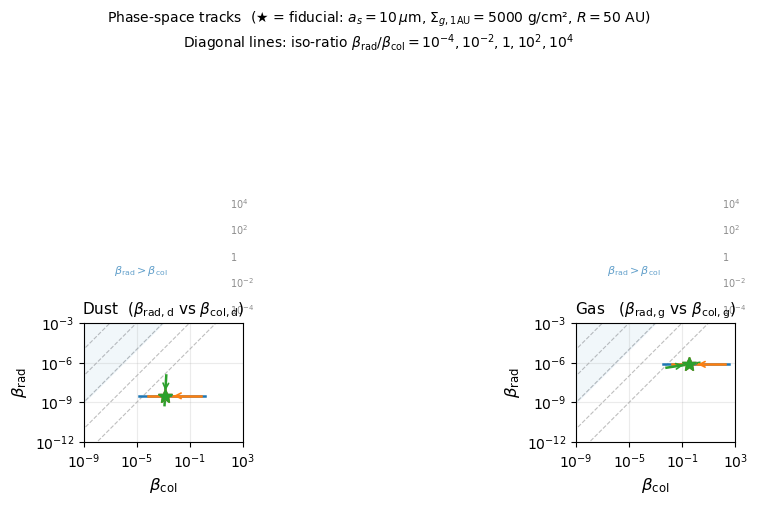

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Three parameter tracks in (β_col, β_rad) phase space ─────────────────────
fid = dict(a_s=10e-4, Sigma_g_1au=5000.0, R=50.0)

tracks = [
    ("a_s",         np.logspace(-5, 0, 300),
     dict(Sigma_g_1au=fid["Sigma_g_1au"], R=fid["R"]),
     r"vary $a_s$",         "C0"),
    ("Sigma_g_1au", np.logspace(1, 5, 300),
     dict(a_s=fid["a_s"],  R=fid["R"]),
     r"vary $\Sigma_{g,1\rm AU}$", "C1"),
    ("R",           np.logspace(0, np.log10(300), 300),
     dict(a_s=fid["a_s"],  Sigma_g_1au=fid["Sigma_g_1au"]),
     r"vary $R$",           "C2"),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ax_d, ax_g = axes

# ── Diagonal iso-ratio lines ──────────────────────────────────────────────────
beta_ref = np.logspace(-12, 2, 200)
for ratio, lstr in [(1e-4, r"$10^{-4}$"), (1e-2, r"$10^{-2}$"),
                    (1.0,  r"$1$"),        (1e2,  r"$10^{2}$"),
                    (1e4,  r"$10^{4}$")]:
    kw = dict(color="0.75", lw=0.8, ls="--", zorder=0)
    ax_d.plot(beta_ref, ratio * beta_ref, **kw)
    ax_g.plot(beta_ref, ratio * beta_ref, **kw)
    # label at right edge
    y_d = ratio * beta_ref[-1]
    y_g = ratio * beta_ref[-1]
    for ax, y in [(ax_d, y_d), (ax_g, y_g)]:
        ax.text(beta_ref[-1] * 1.05, y, lstr, fontsize=7,
                color="0.55", va="center", ha="left")

# ── Plot each track ───────────────────────────────────────────────────────────
for sweep_key, sweep_vals, fixed_kw, track_label, color in tracks:
    bc_d = np.empty(len(sweep_vals))
    br_d = np.empty(len(sweep_vals))
    bc_g = np.empty(len(sweep_vals))
    br_g = np.empty(len(sweep_vals))

    for i, v in enumerate(sweep_vals):
        kw = dict(fixed_kw); kw[sweep_key] = v
        r = local_cooling_betas(**kw)
        bc_d[i] = r["beta_col_d"]; br_d[i] = r["beta_rad_d"]
        bc_g[i] = r["beta_col_g"]; br_g[i] = r["beta_rad_g"]

    # mark fiducial point (middle of sweep) with a star
    kw_fid = dict(fid); r_fid = local_cooling_betas(**kw_fid)

    for ax, bc, br, fid_bc, fid_br in [
        (ax_d, bc_d, br_d, r_fid["beta_col_d"], r_fid["beta_rad_d"]),
        (ax_g, bc_g, br_g, r_fid["beta_col_g"], r_fid["beta_rad_g"]),
    ]:
        ax.plot(bc, br, color=color, lw=1.8, label=track_label)
        # arrow to indicate direction of increasing sweep value
        mid = len(sweep_vals) // 2
        ax.annotate("", xy=(bc[mid+3], br[mid+3]), xytext=(bc[mid-3], br[mid-3]),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.2))
        ax.plot(fid_bc, fid_br, "*", color=color, ms=10, zorder=5)

# ── Axes formatting ───────────────────────────────────────────────────────────
for ax, title in [(ax_d, r"Dust  ($\beta_{\rm rad,d}$ vs $\beta_{\rm col,d}$)"),
                  (ax_g, r"Gas   ($\beta_{\rm rad,g}$ vs $\beta_{\rm col,g}$)")]:
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(1e-8, 1e3); ax.set_ylim(1e-12, 1e2)
    ax.set_xlabel(r"$\beta_{\rm col}$", fontsize=12)
    ax.set_ylabel(r"$\beta_{\rm rad}$", fontsize=12)
    ax.set_title(title, fontsize=11)
    #ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.08)
    # shade region where β_rad > β_col (radiative cooling dominates)
    xlim = ax.get_xlim(); ylim = ax.get_ylim()
    ax.fill_between([1e-12, 1e6], [1e-12, 1e6], [1e6, 1e6],
                    alpha=0.06, color="C0", zorder=0, label="__nolegend__")
    ax.text(2e-7, 5e0, r"$\beta_{\rm rad}>\beta_{\rm col}$",
            fontsize=8, color="C0", alpha=0.7)
    
    ax.axis("scaled")
    ax.set_xlim([1e-9, 1e3])
    ax.set_ylim([1e-12, 1e-3])
    

fig.suptitle(
    r"Phase-space tracks  (★ = fiducial: $a_s=10\,\mu$m, $\Sigma_{g,1\rm AU}=5000$ g/cm², $R=50$ AU)"
    "\nDiagonal lines: iso-ratio $\\beta_{\\rm rad}/\\beta_{\\rm col}=10^{-4},10^{-2},1,10^2,10^4$",
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()


/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_38074/3562618207.py:237: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([-1e-9, 1e3])
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_38074/3562618207.py:238: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([-1e-9, 1e3])


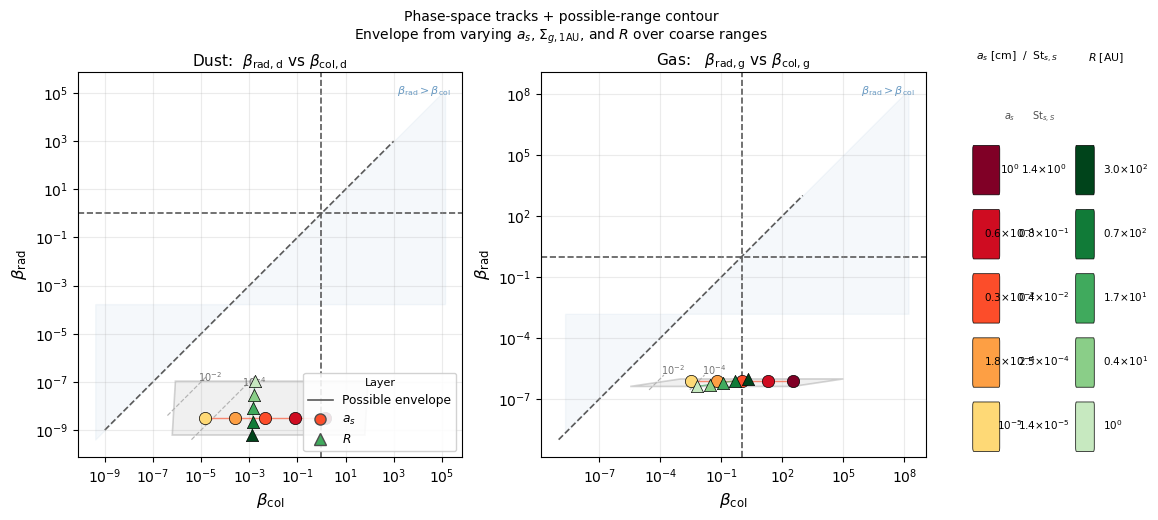

In [33]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# -- 5 discrete sample values per displayed track ------------------------------
N = 5
FID = dict(a_s=10e-4, Sigma_g_1au=5000.0, R=50.0)

track_specs = [
    (
        "a_s",
        np.logspace(-5, 0, N),
        dict(Sigma_g_1au=FID["Sigma_g_1au"], R=FID["R"]),
        r"$a_s$ [cm]  /  $\mathrm{St}_{s,S}$",
        "YlOrRd",
        "o",
    ),
    (
        "R",
        np.logspace(0, np.log10(300), N),
        dict(a_s=FID["a_s"], Sigma_g_1au=FID["Sigma_g_1au"]),
        r"$R$ [AU]",
        "Greens",
        "^",
    ),
]

# -- Coarse ranges for full possible parameter envelope ------------------------
RANGE = {
    "a_s": np.logspace(-5, 0, 12),          # cm
    "Sigma_g_1au": np.logspace(2, 5, 12),   # g cm^-2
    "R": np.logspace(0, np.log10(300), 12), # AU
}

def fmt_log(v):
    exp = int(np.round(np.log10(v)))
    man = v / 10 ** exp
    if abs(man - 1) < 0.05:
        return f"$10^{{{exp}}}$"
    return f"${man:.1f}\\!\\times\\!10^{{{exp}}}$"

# -- Build cloud by varying (a_s, Sigma_g_1au, R) jointly ---------------------
beta_col_d_cloud, beta_rad_d_cloud = [], []
beta_col_g_cloud, beta_rad_g_cloud = [], []

for a_s_v in RANGE["a_s"]:
    for s1_v in RANGE["Sigma_g_1au"]:
        for r_v in RANGE["R"]:
            rr = local_cooling_betas(a_s=a_s_v, Sigma_g_1au=s1_v, R=r_v)
            beta_col_d_cloud.append(rr["beta_col_d"])
            beta_rad_d_cloud.append(rr["beta_rad_d"])
            beta_col_g_cloud.append(rr["beta_col_g"])
            beta_rad_g_cloud.append(rr["beta_rad_g"])

beta_col_d_cloud = np.asarray(beta_col_d_cloud)
beta_rad_d_cloud = np.asarray(beta_rad_d_cloud)
beta_col_g_cloud = np.asarray(beta_col_g_cloud)
beta_rad_g_cloud = np.asarray(beta_rad_g_cloud)

# -- Collect track data (a_s and R only) --------------------------------------
all_bc_d, all_br_d, all_bc_g, all_br_g = [], [], [], []
track_data = []
for sweep_key, sweep_vals, fixed_kw, col_title, cmap_name, marker in track_specs:
    bc_d = np.empty(N)
    br_d = np.empty(N)
    bc_g = np.empty(N)
    br_g = np.empty(N)
    st_vals = np.empty(N)

    for i, v in enumerate(sweep_vals):
        kw = dict(fixed_kw)
        kw[sweep_key] = v
        r = local_cooling_betas(**kw)
        bc_d[i] = r["beta_col_d"]
        br_d[i] = r["beta_rad_d"]
        bc_g[i] = r["beta_col_g"]
        br_g[i] = r["beta_rad_g"]
        st_vals[i] = r["St"]

    base_cmap = matplotlib.colormaps[cmap_name]
    colors = [base_cmap(0.25 + 0.75 * i / (N - 1)) for i in range(N)]

    track_data.append(
        (bc_d, br_d, bc_g, br_g, sweep_vals, st_vals, colors, col_title, marker, sweep_key)
    )

    all_bc_d.extend(bc_d)
    all_br_d.extend(br_d)
    all_bc_g.extend(bc_g)
    all_br_g.extend(br_g)

all_bc_d.extend(beta_col_d_cloud)
all_br_d.extend(beta_rad_d_cloud)
all_bc_g.extend(beta_col_g_cloud)
all_br_g.extend(beta_rad_g_cloud)

def padded_lims(vals, pad=0.20):
    lo, hi = np.min(vals), np.max(vals)
    return 10 ** (np.log10(lo) - pad), 10 ** (np.log10(hi) + pad)

xlim_d = padded_lims(np.asarray(all_bc_d))
ylim_d = padded_lims(np.asarray(all_br_d))
xlim_g = padded_lims(np.asarray(all_bc_g))
ylim_g = padded_lims(np.asarray(all_br_g))

# -- Figure layout -------------------------------------------------------------
fig = plt.figure(figsize=(12, 5.2))
gs = fig.add_gridspec(
    1, 4,
    width_ratios=[4, 4, 0.80, 0.55],
    wspace=0.05,
    left=0.07,
    right=0.98,
    top=0.86,
    bottom=0.12,
)
ax_d = fig.add_subplot(gs[0])
ax_g = fig.add_subplot(gs[1])
leg_axes = [fig.add_subplot(gs[2 + i]) for i in range(2)]
for lax in leg_axes:
    lax.axis("off")

# -- Convex-hull envelope in log-space (smooth, no binning kinks) -------------
def _cross(o, a, b):
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

def convex_hull(points):
    pts = np.array(sorted(points.tolist()))
    if len(pts) <= 2:
        return pts
    lower = []
    for p in pts:
        while len(lower) >= 2 and _cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(tuple(p))
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and _cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(tuple(p))
    hull = np.array(lower[:-1] + upper[:-1])
    return hull

def draw_possible_envelope(ax, xvals, yvals, fill_color="0.78", edge_color="0.35"):
    pts = np.column_stack([np.log10(xvals), np.log10(yvals)])
    pts = np.unique(pts, axis=0)
    if len(pts) < 3:
        return
    hull = convex_hull(pts)
    hx = 10 ** hull[:, 0]
    hy = 10 ** hull[:, 1]
    ax.fill(hx, hy, facecolor=fill_color, edgecolor=edge_color, linewidth=1.2, alpha=0.25, zorder=0)

draw_possible_envelope(ax_d, beta_col_d_cloud, beta_rad_d_cloud)
draw_possible_envelope(ax_g, beta_col_g_cloud, beta_rad_g_cloud)

# -- Diagonal iso-ratio lines --------------------------------------------------
RATIOS = [1e-4, 1e-2, 1e0, 1e2, 1e4]
RLBLS = [r"$10^{-4}$", r"$10^{-2}$", r"$1$", r"$10^{2}$", r"$10^{4}$"]
for ax, xlim, ylim in [(ax_d, xlim_d, ylim_d), (ax_g, xlim_g, ylim_g)]:
    x_ref = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), 300)
    for ratio, rlbl in zip(RATIOS, RLBLS):
        y_ref = ratio * x_ref
        mask = (y_ref >= ylim[0]) & (y_ref <= ylim[1])
        if mask.sum() < 2:
            continue
        xm = x_ref[mask]
        ym = y_ref[mask]
        ax.plot(xm, ym, color="0.70", lw=0.85, ls="--", zorder=1)
        jlab = int(0.80 * (len(xm) - 1))
        ax.text(xm[jlab], ym[jlab] * 1.08, rlbl, fontsize=7, color="0.45", ha="left", va="bottom")

# -- Overlay discrete tracks ---------------------------------------------------
shape_handles = [
    plt.Line2D([0], [0], color="0.35", lw=1.2, label="Possible envelope"),
]

for bc_d, br_d, bc_g, br_g, sweep_vals, st_vals, colors, col_title, marker, sweep_key in track_data:
    for ax, bc, br in [(ax_d, bc_d, br_d), (ax_g, bc_g, br_g)]:
        ax.plot(bc, br, color=colors[N // 2], lw=1.0, alpha=0.65, zorder=2)
        for i in range(N):
            ax.scatter(
                bc[i], br[i], color=colors[i], s=78, marker=marker, zorder=3,
                edgecolors="k", linewidths=0.5
            )

    shape_handles.append(
        plt.Line2D(
            [0], [0], marker=marker, color="0.3",
            markerfacecolor=colors[N // 2], ms=8, lw=0,
            label=col_title.split("[")[0].split("/")[0].strip(),
        )
    )

# -- Side legend columns -------------------------------------------------------
for lax, (_, _, _, _, sweep_vals, st_vals, colors, col_title, marker, sweep_key) in zip(leg_axes, track_data):
    lax.text(0.5, 1.02, col_title, ha="center", va="bottom", fontsize=7.8, transform=lax.transAxes)

    show_st = sweep_key == "a_s"
    step = 1.0 / (N + 1)

    if show_st:
        lax.text(0.42, 1.0 - step * 0.7, r"$a_s$", ha="center", va="center", fontsize=7, color="0.3", transform=lax.transAxes)
        lax.text(0.80, 1.0 - step * 0.7, r"$\mathrm{St}_{s,S}$", ha="center", va="center", fontsize=7, color="0.3", transform=lax.transAxes)

    for j in range(N):
        rank = N - 1 - j
        ypos = 1.0 - step * (j + 1.5)

        patch = mpatches.FancyBboxPatch(
            (0.02, ypos - step * 0.35),
            0.28,
            step * 0.65,
            boxstyle="round,pad=0.01",
            facecolor=colors[rank],
            edgecolor="k",
            linewidth=0.5,
            transform=lax.transAxes,
            clip_on=False,
        )
        lax.add_patch(patch)

        if show_st:
            lax.text(0.42, ypos, fmt_log(sweep_vals[rank]), ha="center", va="center", fontsize=7.5, transform=lax.transAxes)
            lax.text(0.80, ypos, fmt_log(st_vals[rank]), ha="center", va="center", fontsize=7.5, transform=lax.transAxes)
        else:
            lax.text(0.45, ypos, fmt_log(sweep_vals[rank]), ha="left", va="center", fontsize=7.5, transform=lax.transAxes)

# -- Axis formatting -----------------------------------------------------------
for ax, xlim, ylim, title in [
    (ax_d, xlim_d, ylim_d, r"Dust:  $\beta_{\rm rad,d}$ vs $\beta_{\rm col,d}$"),
    (ax_g, xlim_g, ylim_g, r"Gas:   $\beta_{\rm rad,g}$ vs $\beta_{\rm col,g}$"),
]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim([-1e-9, 1e3])
    ax.set_ylim([-1e-9, 1e3])
    ax.set_xlabel(r"$\beta_{\rm col}$", fontsize=12)
    ax.set_ylabel(r"$\beta_{\rm rad}$", fontsize=12)
    
    ax.set_title(title, fontsize=11, pad=4)
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.08)
    ax.axvline(x=1, color="0.35", lw=1.2, ls="--", zorder=1)
    ax.axhline(y=1, color="0.35", lw=1.2, ls="--", zorder=1)
    ax.plot([1e-9, 1e3], [1e-9, 1e3], color="0.35", lw=1.2, ls="--", zorder=1)

    xfill = [xlim[0] * 1e-3, xlim[1] * 1e3]
    ax.fill_between(xfill, xfill, [ylim[1] * 1e3] * 2, alpha=0.05, color="steelblue", zorder=0)
    ax.text(0.97, 0.97, r"$\beta_{\rm rad}>\beta_{\rm col}$", transform=ax.transAxes, fontsize=8, color="steelblue", ha="right", va="top", alpha=0.8)
    ax.axis("scaled")

ax_d.legend(handles=shape_handles, fontsize=8.8, loc="lower right", title="Layer", title_fontsize=8, framealpha=0.88)

fig.suptitle(
    r"Phase-space tracks + possible-range contour"
    "\nEnvelope from varying $a_s$, $\\Sigma_{g,1\\rm AU}$, and $R$ over coarse ranges",
    fontsize=10,
)
plt.show()


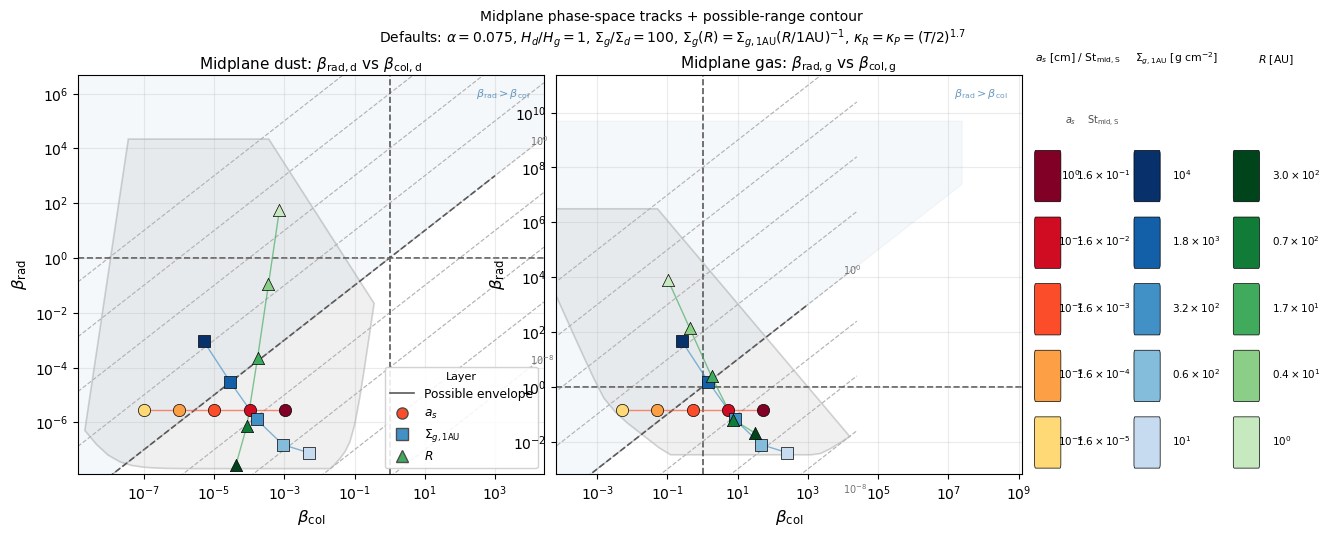

In [38]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Midplane model assumptions requested by user:
# - T_eq = alpha_grazing^(1/4) * (R_star / R)^(1/2) * T_star
# - kappa_R,d = kappa_P,d = (T/2)^1.7
# - c_d(T) = 10*T^3
# - H_d/H_g = 1 (default)
# - Sigma_g/Sigma_d = 100 (default)
# - Sigma_g(R) = Sigma_g,1AU * (R / 1 AU)^(-1)


def sigma_g_profile(Sigma_g_1au, R):
    return Sigma_g_1au * (R / 1.0) ** (-1.0)


def midplane_cooling_betas(
    a_s,                           # grain size [cm]
    Sigma_g_1au,                   # gas surface density at 1 AU [g cm^-2]
    R,                             # orbital radius [AU]
    alpha_grazing=0.075,           # grazing angle
    T_star=T_sun,
    M_star=M_sun,
    R_star=R_sun,
    Sigma_g_over_Sigma_d=100.0,    # Sigma_g / Sigma_d
    Hd_over_Hg=1.0,
    alpha_T=1.0,
    rho_int=1.0,
    gamma_g=1.4,
    mu=2.3,
):
    R_cm = R * AU
    Sigma_g = sigma_g_profile(Sigma_g_1au, R)

    # Irradiation-set midplane temperature.
    T_eq = alpha_grazing ** 0.25 * (R_star / R_cm) ** 0.5 * T_star

    kappa = (T_eq / 2.0) ** 1.7
    c_d = 10.0 * T_eq ** 3
    c_p = (7.0 / 2.0) * k_B / (mu * m_H)

    Omega = np.sqrt(G * M_star / R_cm**3)

    Sigma_d = Sigma_g / Sigma_g_over_Sigma_d
    tau_R = 0.5 * kappa * Sigma_d
    tau_P = 0.5 * kappa * Sigma_d
    tau_eff = (3.0 * tau_R / 8.0) + (np.sqrt(3.0) / 4.0) + (1.0 / (4.0 * tau_P))

    St_mid = (np.pi / 2.0) * (a_s * rho_int / Sigma_g)

    beta_rad_d = (Sigma_d * c_d * tau_eff * Omega) / (8.0 * sigma_SB * T_eq**3)
    beta_rad_g = (Sigma_g * c_p * tau_eff * Omega) / (8.0 * sigma_SB * T_eq**3)

    pref = (1.0 / alpha_T) * (2.0 / 3.0) * (gamma_g / (gamma_g - 1.0))
    geom = np.sqrt(1.0 + Hd_over_Hg**2)
    beta_col_d = pref * (c_d / c_p) * geom * St_mid
    beta_col_g = pref * Sigma_g_over_Sigma_d * geom * St_mid

    return dict(
        Sigma_g=Sigma_g,
        T_eq=T_eq,
        kappa=kappa,
        c_d=c_d,
        c_p=c_p,
        Omega=Omega,
        Sigma_d=Sigma_d,
        tau_eff=tau_eff,
        St_mid=St_mid,
        beta_rad_d=beta_rad_d,
        beta_rad_g=beta_rad_g,
        beta_col_d=beta_col_d,
        beta_col_g=beta_col_g,
    )


def fmt_log(v):
    e = int(np.round(np.log10(v)))
    m = v / 10**e
    if np.isclose(m, 1.0, rtol=0.02, atol=0.02):
        return f"$10^{{{e}}}$"
    return f"${m:.1f}\\times10^{{{e}}}$"


def ratio_label(r):
    e = int(np.round(np.log10(r)))
    return f"$10^{{{e}}}$"


def _cross(o, a, b):
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


def convex_hull(points):
    pts = np.array(sorted(points.tolist()))
    if len(pts) <= 2:
        return pts
    lower = []
    for p in pts:
        while len(lower) >= 2 and _cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(tuple(p))
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and _cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(tuple(p))
    return np.array(lower[:-1] + upper[:-1])


def draw_possible_envelope(ax, xvals, yvals, fill_color="0.78", edge_color="0.35"):
    pts = np.column_stack([np.log10(xvals), np.log10(yvals)])
    pts = np.unique(pts, axis=0)
    if len(pts) < 3:
        return
    hull = convex_hull(pts)
    hx = 10 ** hull[:, 0]
    hy = 10 ** hull[:, 1]
    ax.fill(hx, hy, facecolor=fill_color, edgecolor=edge_color, linewidth=1.2, alpha=0.25, zorder=0)


# -- Midplane plotting setup ----------------------------------------------------
N = 5
FID = dict(a_s=10e-2, Sigma_g_1au=500.0, R=50.0)

track_specs = [
    ("a_s", np.logspace(-4, 0, N), dict(Sigma_g_1au=FID["Sigma_g_1au"], R=FID["R"]), r"$a_s$ [cm] / $\mathrm{St}_{\rm mid,S}$", "YlOrRd", "o"),
    ("Sigma_g_1au", np.logspace(1, 4, N), dict(a_s=FID["a_s"], R=FID["R"]), r"$\Sigma_{g,1\rm AU}$ [g cm$^{-2}$]", "Blues", "s"),
    ("R", np.logspace(0, np.log10(300), N), dict(a_s=FID["a_s"], Sigma_g_1au=FID["Sigma_g_1au"]), r"$R$ [AU]", "Greens", "^"),
]

RANGE = {
    "a_s": np.logspace(-4, 0, 10),
    "Sigma_g_1au": np.logspace(1, 4, 10),
    "R": np.logspace(0, np.log10(300), 10),
}

# Full-parameter cloud for envelope.
bc_d_cloud, br_d_cloud, bc_g_cloud, br_g_cloud = [], [], [], []
for a_s_v in RANGE["a_s"]:
    for sig1_v in RANGE["Sigma_g_1au"]:
        for r_v in RANGE["R"]:
            rr = midplane_cooling_betas(a_s=a_s_v, Sigma_g_1au=sig1_v, R=r_v)
            bc_d_cloud.append(rr["beta_col_d"])
            br_d_cloud.append(rr["beta_rad_d"])
            bc_g_cloud.append(rr["beta_col_g"])
            br_g_cloud.append(rr["beta_rad_g"])

bc_d_cloud = np.asarray(bc_d_cloud)
br_d_cloud = np.asarray(br_d_cloud)
bc_g_cloud = np.asarray(bc_g_cloud)
br_g_cloud = np.asarray(br_g_cloud)

track_data = []
all_bc_d, all_br_d = list(bc_d_cloud), list(br_d_cloud)
all_bc_g, all_br_g = list(bc_g_cloud), list(br_g_cloud)

for sweep_key, sweep_vals, fixed_kw, col_title, cmap_name, marker in track_specs:
    bc_d = np.empty(N); br_d = np.empty(N)
    bc_g = np.empty(N); br_g = np.empty(N)
    st_vals = np.empty(N)

    for i, v in enumerate(sweep_vals):
        kw = dict(fixed_kw); kw[sweep_key] = v
        r = midplane_cooling_betas(**kw)
        bc_d[i] = r["beta_col_d"]; br_d[i] = r["beta_rad_d"]
        bc_g[i] = r["beta_col_g"]; br_g[i] = r["beta_rad_g"]
        st_vals[i] = r["St_mid"]

    cmap = matplotlib.colormaps[cmap_name]
    colors = [cmap(0.25 + 0.75 * i / (N - 1)) for i in range(N)]
    track_data.append((bc_d, br_d, bc_g, br_g, sweep_vals, st_vals, colors, col_title, marker, sweep_key))

    all_bc_d.extend(bc_d); all_br_d.extend(br_d)
    all_bc_g.extend(bc_g); all_br_g.extend(br_g)


def padded_lims(vals, pad=0.20):
    lo, hi = np.min(vals), np.max(vals)
    return 10 ** (np.log10(lo) - pad), 10 ** (np.log10(hi) + pad)

xlim_d = padded_lims(np.asarray(all_bc_d)); ylim_d = padded_lims(np.asarray(all_br_d))
xlim_g = padded_lims(np.asarray(all_bc_g)); ylim_g = padded_lims(np.asarray(all_br_g))

# Shared limits for left/right panels.
xlim_common = (min(xlim_d[0], xlim_g[0]), max(xlim_d[1], xlim_g[1]))
ylim_common = (min(ylim_d[0], ylim_g[0]), max(ylim_d[1], ylim_g[1]))

fig = plt.figure(figsize=(13.5, 5.4))
gs = fig.add_gridspec(1, 5, width_ratios=[4, 4, 0.75, 0.75, 0.75], wspace=0.05,
                      left=0.06, right=0.98, top=0.86, bottom=0.12)
ax_d = fig.add_subplot(gs[0])
ax_g = fig.add_subplot(gs[1])
leg_axes = [fig.add_subplot(gs[2 + i]) for i in range(3)]
for lax in leg_axes:
    lax.axis("off")

# Envelope.
draw_possible_envelope(ax_d, bc_d_cloud, br_d_cloud)
draw_possible_envelope(ax_g, bc_g_cloud, br_g_cloud)

# Same ratio-line style on full figure.
RATIOS = np.logspace(-8, 8, 9)
KEY_LABELS = [1e-8, 1.0, 1e8]
for ax in [ax_d, ax_g]:
    x_ref = np.logspace(np.log10(xlim_common[0]), np.log10(xlim_common[1]), 300)
    for ratio in RATIOS:
        y_ref = ratio * x_ref
        ax.plot(x_ref, y_ref, color="0.70", lw=0.85, ls="--", zorder=1)
        if any(np.isclose(ratio, v) for v in KEY_LABELS):
            xlab = xlim_common[1] / 2.5
            ylab = ratio * xlab
            if ylim_common[0] < ylab < ylim_common[1]:
                ax.text(xlab, ylab * 1.06, ratio_label(ratio), fontsize=7, color="0.45",
                        ha="left", va="bottom")

# Tracks.
shape_handles = [plt.Line2D([0], [0], color="0.35", lw=1.2, label="Possible envelope")]
for bc_d, br_d, bc_g, br_g, sweep_vals, st_vals, colors, col_title, marker, sweep_key in track_data:
    for ax, bc, br in [(ax_d, bc_d, br_d), (ax_g, bc_g, br_g)]:
        ax.plot(bc, br, color=colors[N // 2], lw=1.0, alpha=0.65, zorder=2)
        for i in range(N):
            ax.scatter(bc[i], br[i], color=colors[i], s=78, marker=marker,
                       zorder=3, edgecolors="k", linewidths=0.5)
    shape_handles.append(
        plt.Line2D([0], [0], marker=marker, color="0.3", markerfacecolor=colors[N // 2],
                   ms=8, lw=0, label=col_title.split("[")[0].split("/")[0].strip())
    )

# Side legends.
for lax, (_, _, _, _, sweep_vals, st_vals, colors, col_title, _, sweep_key) in zip(leg_axes, track_data):
    lax.text(0.5, 1.02, col_title, ha="center", va="bottom", fontsize=7.8, transform=lax.transAxes)
    show_st = (sweep_key == "a_s")
    step = 1.0 / (N + 1)

    if show_st:
        lax.text(0.42, 1.0 - step * 0.7, r"$a_s$", ha="center", va="center", fontsize=7,
                 color="0.3", transform=lax.transAxes)
        lax.text(0.80, 1.0 - step * 0.7, r"$\mathrm{St}_{\rm mid,S}$", ha="center", va="center",
                 fontsize=7, color="0.3", transform=lax.transAxes)

    for j in range(N):
        rank = N - 1 - j
        ypos = 1.0 - step * (j + 1.5)
        patch = mpatches.FancyBboxPatch(
            (0.02, ypos - step * 0.35), 0.28, step * 0.65,
            boxstyle="round,pad=0.01", facecolor=colors[rank], edgecolor="k", linewidth=0.5,
            transform=lax.transAxes, clip_on=False
        )
        lax.add_patch(patch)

        if show_st:
            lax.text(0.42, ypos, fmt_log(sweep_vals[rank]), ha="center", va="center", fontsize=7.5,
                     transform=lax.transAxes)
            lax.text(0.80, ypos, fmt_log(st_vals[rank]), ha="center", va="center", fontsize=7.5,
                     transform=lax.transAxes)
        else:
            lax.text(0.45, ypos, fmt_log(sweep_vals[rank]), ha="left", va="center", fontsize=7.5,
                     transform=lax.transAxes)

# Axes.
for ax, title in [
    (ax_d, r"Midplane dust: $\beta_{\rm rad,d}$ vs $\beta_{\rm col,d}$"),
    (ax_g, r"Midplane gas: $\beta_{\rm rad,g}$ vs $\beta_{\rm col,g}$"),
]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    if ax == ax_g:
        ax.set_xlim(np.array(xlim_common)*5e4)
        ax.set_ylim(np.array(ylim_common)*5e4)
    else:
        ax.set_xlim(np.array(xlim_common))
        ax.set_ylim(np.array(ylim_common))
    ax.set_xlabel(r"$\beta_{\rm col}$", fontsize=12)
    ax.set_ylabel(r"$\beta_{\rm rad}$", fontsize=12)
    ax.set_title(title, fontsize=11, pad=4)
    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.08)

    xfill = [xlim_common[0] * 1e-3, xlim_common[1] * 1e3]
    ax.fill_between(xfill, xfill, [ylim_common[1] * 1e3] * 2, alpha=0.05, color="steelblue", zorder=0)
    ax.text(0.97, 0.97, r"$\beta_{\rm rad}>\beta_{\rm col}$", transform=ax.transAxes,
            fontsize=8, color="steelblue", ha="right", va="top", alpha=0.8)
    ax.axvline(x=1, color="0.35", lw=1.2, ls="--", zorder=1)
    ax.axhline(y=1, color="0.35", lw=1.2, ls="--", zorder=1)
    ax.plot([1e-9, 1e3], [1e-9, 1e3], color="0.35", lw=1.2, ls="--", zorder=1)

ax_d.legend(handles=shape_handles, fontsize=8.8, loc="lower right", title="Layer",
            title_fontsize=8, framealpha=0.88)

fig.suptitle(
    r"Midplane phase-space tracks + possible-range contour"
    "\nDefaults: $\\alpha=0.075$, $H_d/H_g=1$, $\\Sigma_g/\\Sigma_d=100$, $\\Sigma_g(R)=\\Sigma_{g,1\\rm AU}(R/1\\rm AU)^{-1}$, $\\kappa_R=\\kappa_P=(T/2)^{1.7}$",
    fontsize=10,
)
plt.show()